In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Rutas a las carpetas que generaste en los pasos anteriores
RAW_PDF_DIR = "pdfs_raw"
CLEANED_TEXT_DIR = "text_cleaned"
CHUNKS_DIR = "chunks_ready"

In [3]:
# Contar archivos
num_pdfs = len([f for f in os.listdir(RAW_PDF_DIR) if f.endswith('.pdf')])
num_txts = len([f for f in os.listdir(CLEANED_TEXT_DIR) if f.endswith('.txt')])

print(f"Total de PDFs crudos descargados: {num_pdfs}")
print(f"Total de documentos de texto limpios procesados: {num_txts}")

# Analizar la longitud de los textos limpios
doc_lengths = []
for filename in os.listdir(CLEANED_TEXT_DIR):
    if filename.endswith('.txt'):
        with open(os.path.join(CLEANED_TEXT_DIR, filename), 'r', encoding='utf-8') as f:
            texto = f.read()
            doc_lengths.append(len(texto))

df_docs = pd.DataFrame({"Caracteres_por_Documento": doc_lengths})
print("\nEstadísticas de longitud de los documentos completos (en caracteres):")
display(df_docs.describe())

Total de PDFs crudos descargados: 9
Total de documentos de texto limpios procesados: 9

Estadísticas de longitud de los documentos completos (en caracteres):


,Caracteres_por_Documento
count,9.000000
mean,60826.000000
std,28031.488593
min,16446.000000
25%,52532.000000
50%,59608.000000
75%,79230.000000
max,105939.000000


In [4]:
chunk_data = []

# Leer todos los JSONs generados
for filename in os.listdir(CHUNKS_DIR):
    if filename.endswith('.json'):
        with open(os.path.join(CHUNKS_DIR, filename), 'r', encoding='utf-8') as f:
            chunks = json.load(f)
            for chunk in chunks:
                chunk_data.append({
                    "Documento": chunk["metadata"]["source"],
                    "Longitud": len(chunk["text"]),
                    "Indice": chunk["metadata"]["chunk_index"]
                })

df_chunks = pd.DataFrame(chunk_data)

print(f"Total de chunks generados para la base vectorial: {len(df_chunks)}")
print("\nEstadísticas de longitud de los chunks (en caracteres):")
display(df_chunks["Longitud"].describe())

Total de chunks generados para la base vectorial: 815

Estadísticas de longitud de los chunks (en caracteres):


count     815.000000
mean      740.985276
std       468.557258
min        16.000000
25%       280.500000
50%       898.000000
75%      1194.000000
max      1200.000000
Name: Longitud, dtype: float64

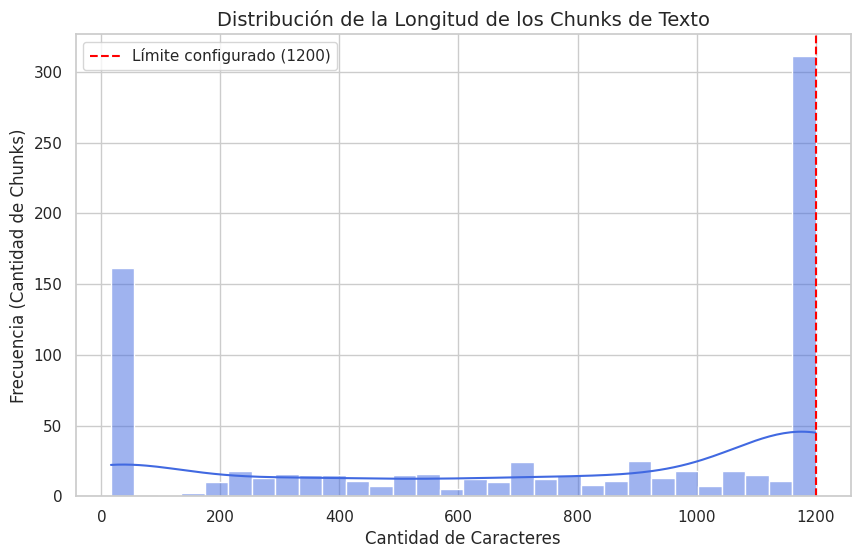

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df_chunks['Longitud'], bins=30, kde=True, color='royalblue')

plt.title('Distribución de la Longitud de los Chunks de Texto', fontsize=14)
plt.xlabel('Cantidad de Caracteres', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Chunks)', fontsize=12)

# Línea roja marcando el límite máximo que configuraste en LangChain (1200)
plt.axvline(x=1200, color='red', linestyle='--', label='Límite configurado (1200)')
plt.legend()
plt.show()